In [1]:
import os
import sys
import shutil
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt

from IPython.display    import display, HTML
from datetime           import date
from sklearn.model_selection    import train_test_split
from methods.Modeling   import Catboost_classificator
from methods.Estimators import (
                                    matrix, 
                                    get_metrics, 
                                    clear_only_files,
                                    BinaryClassificationEvaluator, 
                                    find_best_threshold,
                                    sampling_test,
                                    perform_rfecv,
                                    intervals,
                                    find_feature_importance_catboost,
                                    error_matrix,
                                    total_stata,
                                    mean_absolute_percentage_error,
                                    calculate_columnwise_mape,
                                    save_importances,
                                    plot_roc_lift,
                                    plot_tpr_tnr_intersection,
                                    find_best_threshold_prev,
                                    plot_optimal_proba
                                )

from sklearn.metrics   import (
                                precision_recall_curve,
                                accuracy_score,
                                recall_score,
                                precision_score,
                                roc_auc_score,
                                f1_score
                                
                            )


In [2]:
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(HTML("<style>.container { width:99% !important; }</style>"))
pd.options.display.float_format = '{:,.3f}'.format
pd.set_option('display.max_columns', None)
# ширина каждого столбца (в символах)
pd.set_option('display.max_colwidth', None)

# Фиксируем ВСЕ случайные seed
np.random.seed(0)
import random
random.seed(0)

In [3]:
path = f'prepared_data/data_for_modeling.pickle'
# загрузка данных
with open(path, 'rb') as f:
    samples = pickle.load(f)

# проверим, какие ключи есть в загруженном словаре
print("Ключи в samples:", samples.keys())

Ключи в samples: dict_keys(['train', 'valid', 'test', 'target', 'reasons_df', 'info_fields', 'features', 'cat_features', 'features_intervals'])


In [4]:
train        = samples['train']
valid        = samples['valid']
test         = samples['test']
info         = samples['info_fields']
features     = sorted(samples['features'])
cat_features = samples['cat_features']
target       = samples['target']
reasons_df   = samples['reasons_df']
features_intervals = samples['features_intervals']
build = pd.concat([train, valid])

# Разбиваем на подвыборки

In [5]:
print('======= Распределение таргетов: =======')

print('train:')
print(train[target].value_counts(normalize=True))
print('valid:')
print(valid[target].value_counts(normalize=True))
print('test:')
print(test[target].value_counts(normalize=True))
print('build:')
print(build[target].value_counts(normalize=True))

======= Распределение таргетов: =======
train:
target
0   0.527
1   0.473
Name: proportion, dtype: float64
valid:
target
0   0.528
1   0.472
Name: proportion, dtype: float64
test:
target
0   0.528
1   0.472
Name: proportion, dtype: float64
build:
target
0   0.527
1   0.473
Name: proportion, dtype: float64


In [6]:
print('======= Размер выборок: =======')

print('train:')
print(train.shape)
print('valid:')
print(valid.shape)
print('test:')
print(test.shape)
print('build:')
print(build.shape)

======= Размер выборок: =======
train:
(25565, 26)
valid:
(6392, 26)
test:
(7990, 26)
build:
(31957, 26)


In [7]:
X_train, y_train = train[features], train[target]
X_valid, y_valid = valid[features], valid[target]
X_test, y_test   = test[features], test[target]

# Моделирование

In [26]:
# params = {
#     'loss_function': 'Logloss',
#     'eval_metric': 'AUC',
#     'learning_rate': 0.01,
#     'depth': 7,
#     'l2_leaf_reg': 2,
#     'od_type': 'Iter',
#     'od_wait': 200,
#     'iterations': 2000,  # Больше итераций
#     'auto_class_weights': 'Balanced',
#     'bootstrap_type': 'Bernoulli',
#     'subsample': 0.9,
#     'border_count': 128,  # Увеличиваем количество биннинга
#     'grow_policy': 'SymmetricTree',  # Для более стабильных вероятностей
#     'score_function': 'L2',  # Для лучшей калибровки
#     'min_data_in_leaf': 50,  # Минимум данных в листе
# #     'posterior_sampling': True,  # Включает байесовскую калибровку
# }
params = {
    'auto_class_weights': 'Balanced',
    'loss_function': 'Logloss',
    'early_stopping_rounds': 100,
    'eval_metric': 'AUC',
    'learning_rate':0.1,
    
} 

In [27]:
# объект класса Катбуст
clf_object = Catboost_classificator()
model = clf_object.catboost_base_model_func(X_train[features], y_train, 
                                            X_valid[features], y_valid, 
                                            cat_features , 
                                            params)

0:	test: 0.5511577	best: 0.5511577 (0)	total: 7.74ms	remaining: 7.73s
50:	test: 0.6130090	best: 0.6130090 (50)	total: 321ms	remaining: 5.97s
100:	test: 0.6272891	best: 0.6282348 (95)	total: 626ms	remaining: 5.57s
150:	test: 0.6501465	best: 0.6501465 (150)	total: 930ms	remaining: 5.23s
200:	test: 0.6657874	best: 0.6657874 (200)	total: 1.23s	remaining: 4.9s
250:	test: 0.6694028	best: 0.6694028 (250)	total: 1.54s	remaining: 4.58s
300:	test: 0.6728877	best: 0.6729368 (299)	total: 1.84s	remaining: 4.28s
350:	test: 0.6742190	best: 0.6745783 (346)	total: 2.14s	remaining: 3.96s
400:	test: 0.6752840	best: 0.6755433 (372)	total: 2.44s	remaining: 3.65s
450:	test: 0.6770774	best: 0.6772154 (434)	total: 2.75s	remaining: 3.35s
500:	test: 0.6755313	best: 0.6772154 (434)	total: 3.05s	remaining: 3.04s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6772153614
bestIteration = 434

Shrink model to first 435 iterations.


## importances

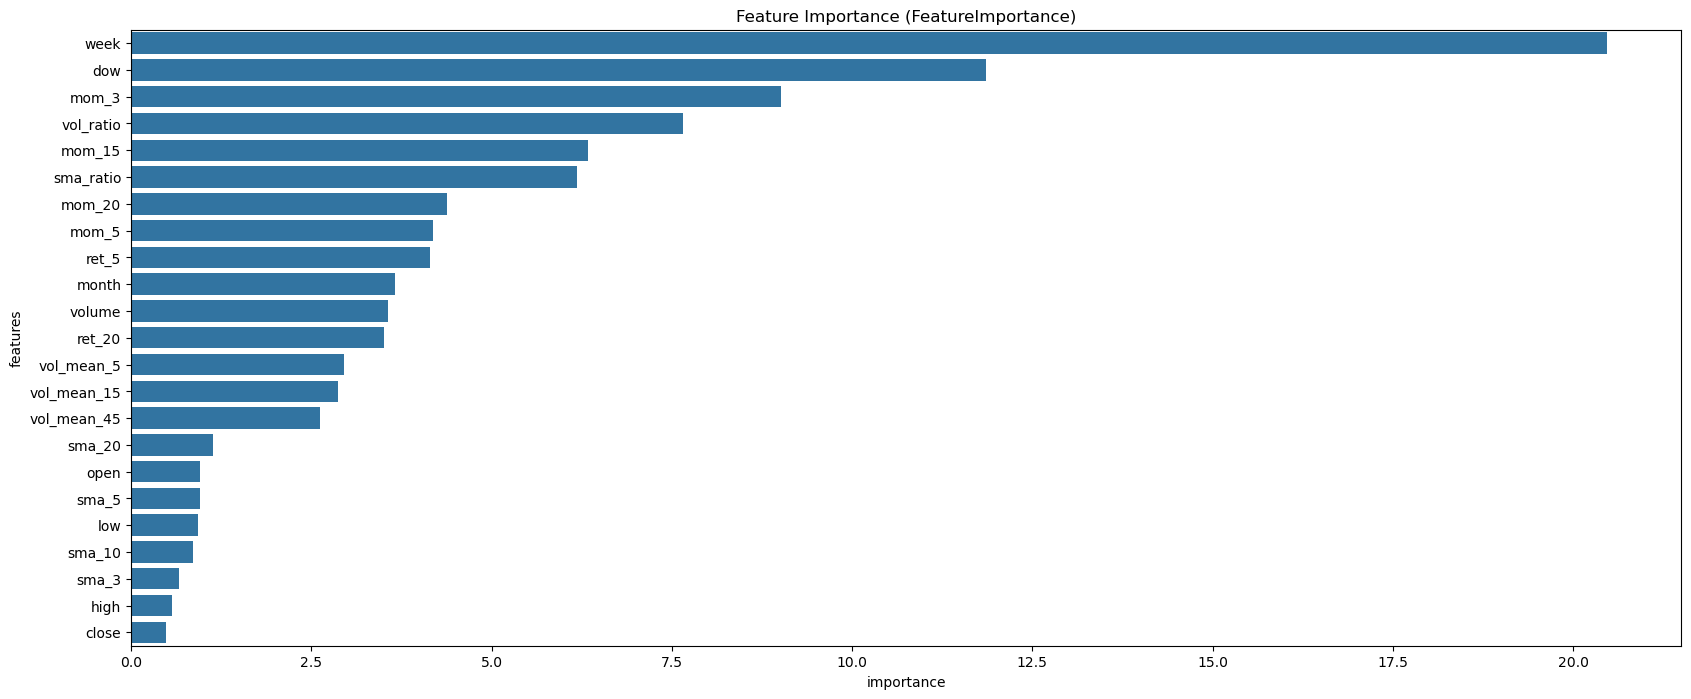

In [28]:
features_importances  = find_feature_importance_catboost(X_train[features], y_train, cat_features, model, 'FeatureImportance', '', False)

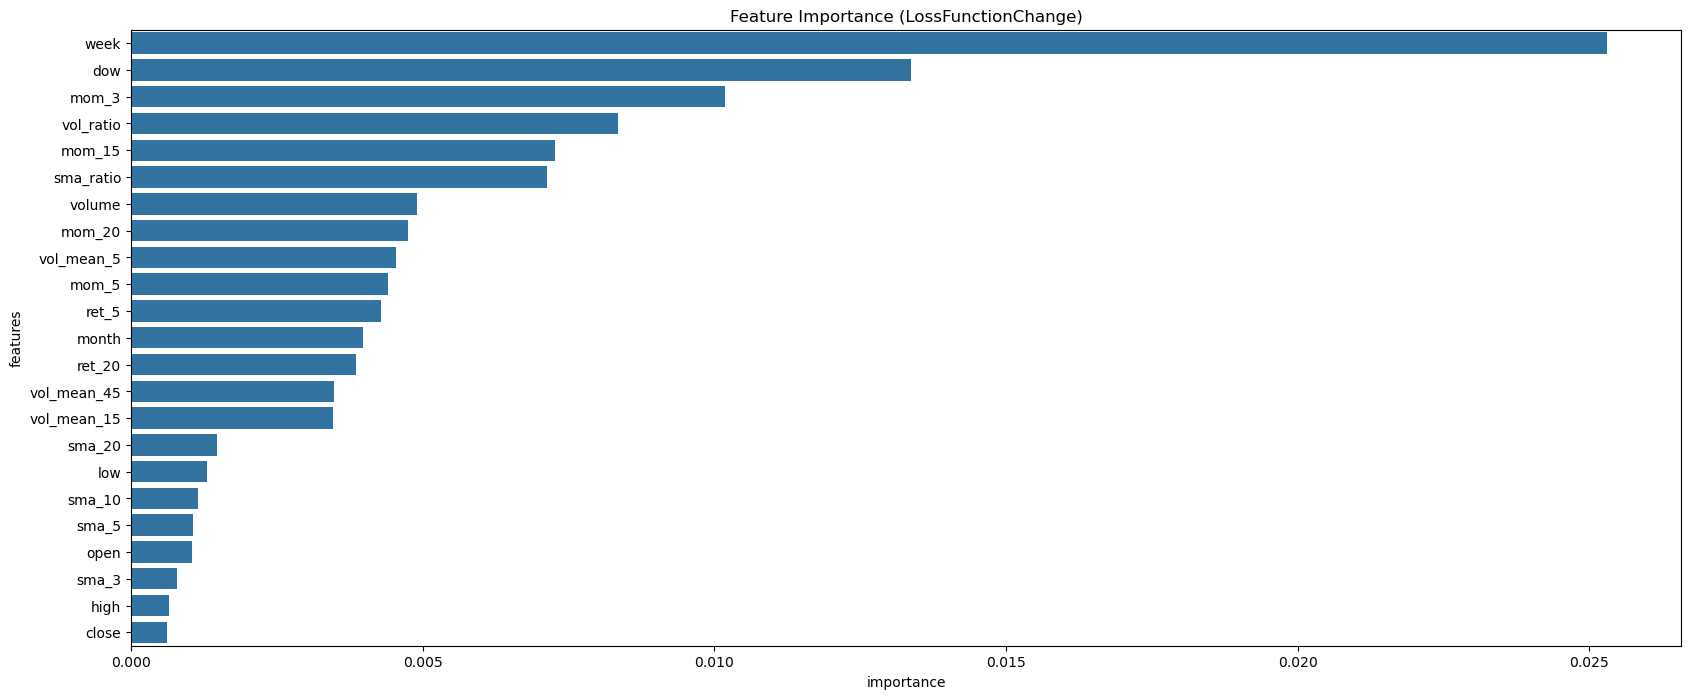

In [29]:
loss_importances      = find_feature_importance_catboost(X_train[features], y_train, cat_features, model, 'LossFunctionChange', '', False)

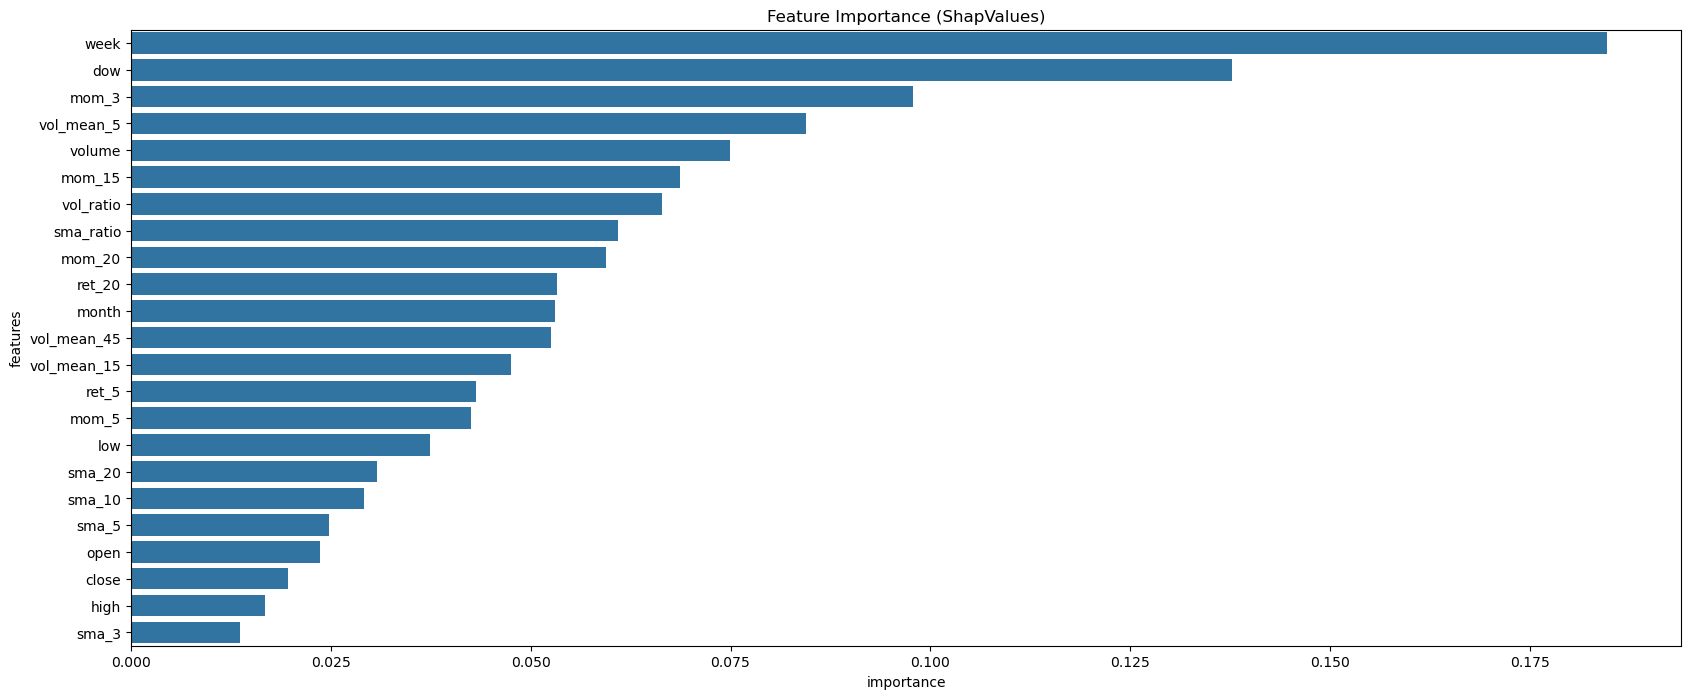

In [30]:
sharp_importances     = find_feature_importance_catboost(X_train[features], y_train, cat_features, model, 'ShapValues', '', False)

# Оптимальный трешхолд по F1

--------Оптимальный трешхолд по F1 -------


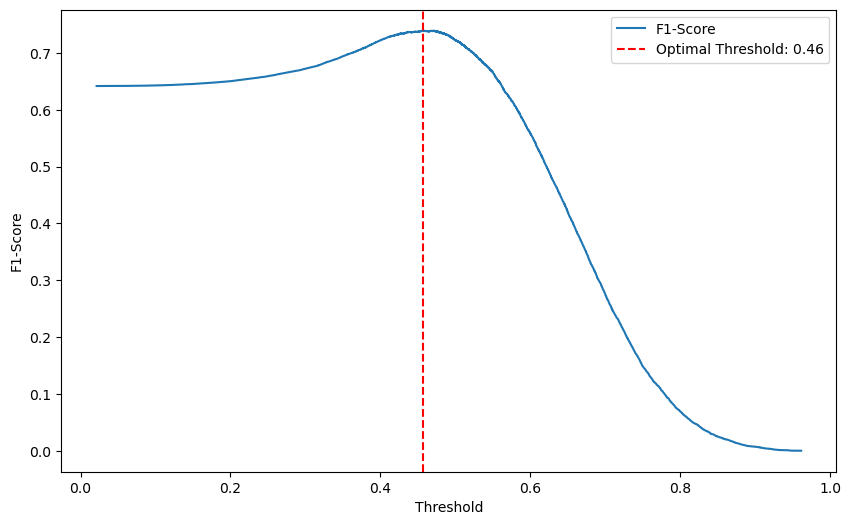

f1_threshold - 0.46, на модели catboost_build_model


In [31]:
print('--------Оптимальный трешхолд по F1 -------')
build_pred_proba = model.predict_proba(build[model.feature_names_])[:, 1]
f1_threshold = plot_optimal_proba(y_true = build[target], y_pred_prob = build_pred_proba, path = '', verbose = False)

f1_threshold = round(f1_threshold, 2)

print(f'f1_threshold - {f1_threshold}, на модели catboost_build_model')

In [32]:
print('------------- Метрики ------------- ')
y_pred_prob = model.predict_proba(X_test[features])[:, 1]  # Predict probabilities for the positive class
y_pred = (y_pred_prob >= f1_threshold).astype(int) #

methods_dict = {
    'binary': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод', 
    'micro': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.', 
    'macro': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)', 
    'weighted': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'
}

metrics_dict = {
    'Accuracy': round(accuracy_score(y_test, y_pred), 3),
    'ROC-AUC': round(roc_auc_score(y_test, y_pred_prob), 3), 
}

for metric_methods, desription in methods_dict.items():
    metrics_dict[metric_methods] = {
        'Метрики': {
            'Precision': round(precision_score(y_test, y_pred, average = metric_methods), 3),
            "Recall"   : round(recall_score(y_test, y_pred, average = metric_methods), 3),
            "F1"       : round(f1_score(y_test, y_pred, average = metric_methods), 3)
        },
        'Описание': desription
}

display(metrics_dict)


------------- Метрики ------------- 


{'Accuracy': 0.605,
 'ROC-AUC': 0.663,
 'binary': {'Метрики': {'Precision': 0.564, 'Recall': 0.725, 'F1': 0.634},
  'Описание': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод'},
 'micro': {'Метрики': {'Precision': 0.605, 'Recall': 0.605, 'F1': 0.605},
  'Описание': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.'},
 'macro': {'Метрики': {'Precision': 0.616, 'Recall': 0.611, 'F1': 0.602},
  'Описание': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)'},
 'weighted': {'Метрики': {'Precision': 0.619, 'Recall': 0.605, 'F1': 0.601},
  'Описание': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'}}

МАТРИЦА ОШИБОК
ROC-AUC: 0.6629114248230461


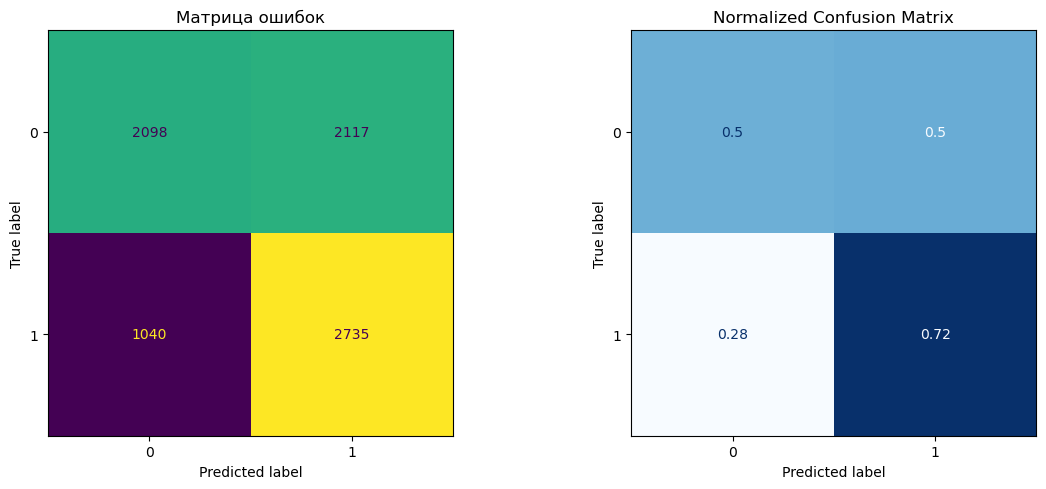

In [33]:
print('МАТРИЦА ОШИБОК')

error_matrix(X_test, y_test, model,f1_threshold)

------------- Графики ------------- 


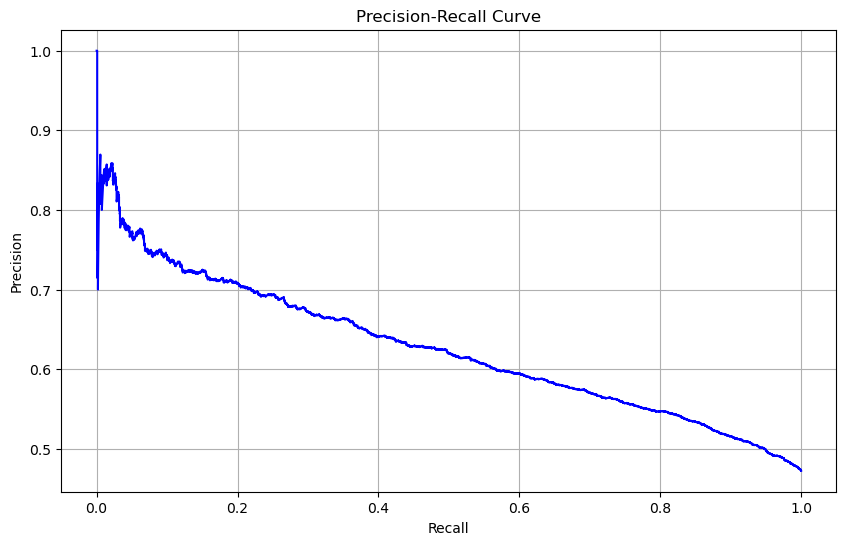

None

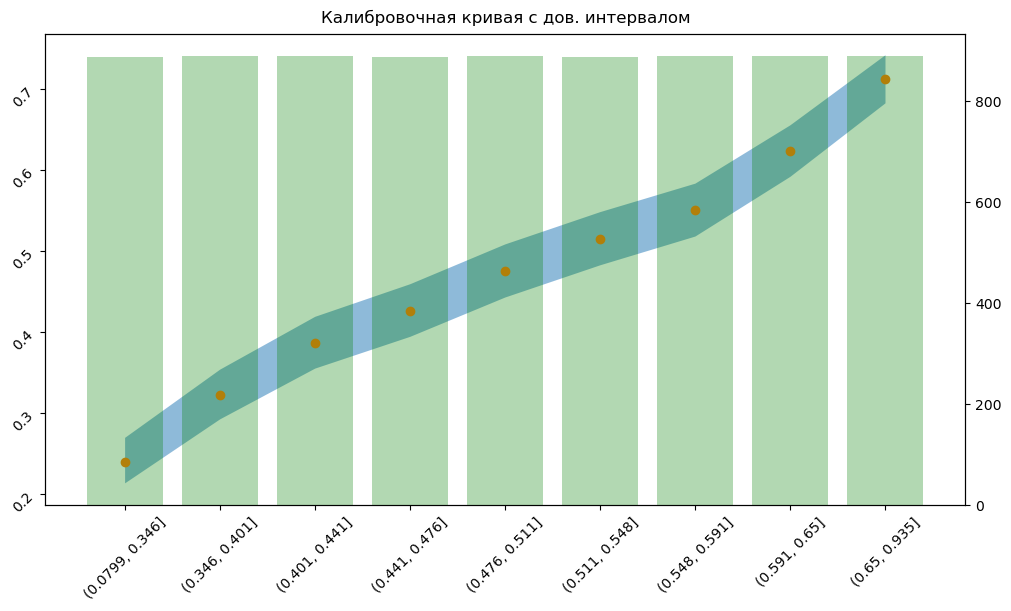

None

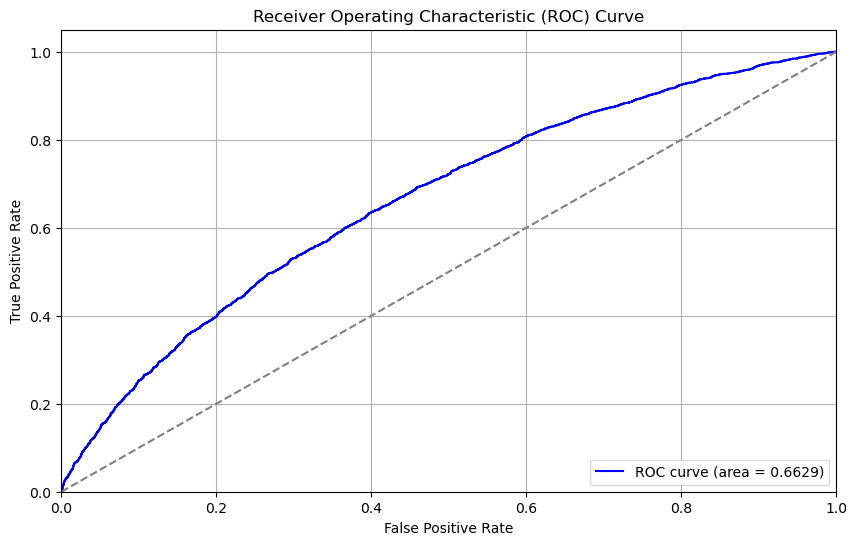

None

In [34]:
print('------------- Графики ------------- ')
metrics_graphs = BinaryClassificationEvaluator(y_test, y_pred, y_pred_prob)
display(metrics_graphs.plot_precision_recall_curve(path = '', verbose =False))
display(metrics_graphs.plot_calibration(path = '', verbose =False))
display(metrics_graphs.plot_roc_curve(path = '', verbose =False))

# Оптимальный трешхолд по FPR/TPR

--------Оптимальный трешхолд по FPR/TPR--------
threshold - 0.5, на модели model


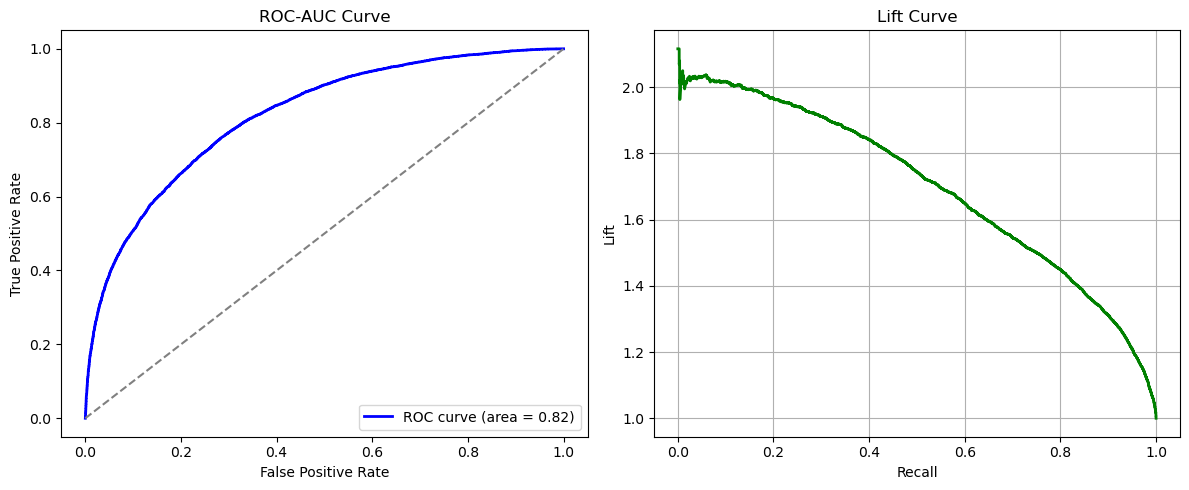

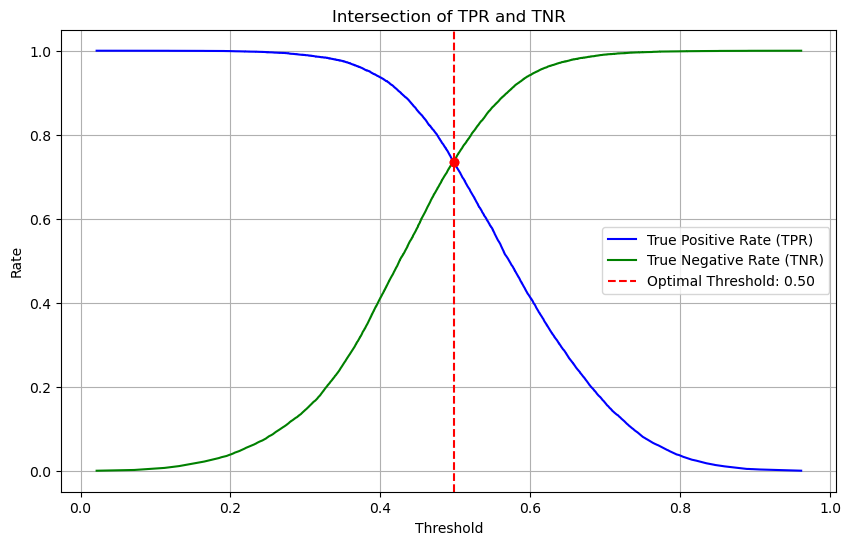

Optimal Threshold: 0.50
TPR at Optimal Threshold: 0.74
TNR at Optimal Threshold: 0.74


In [35]:
print('--------Оптимальный трешхолд по FPR/TPR--------')

build_pred_proba = model.predict_proba(build[model.feature_names_])[:, 1]
threshold, optimal_tpr, optimal_tnr, thresholds, fpr, tpr, tnr = find_best_threshold(y_true = build[target], y_pred_proba = build_pred_proba)
threshold  = round(threshold, 2)
build_pred = (build_pred_proba >= threshold).astype(int)
print(f'threshold - {threshold}, на модели model')

# графики с трешхолдами / verbose = FALSE - чтобы графики не сохранялись, просто посмотреть на них
plot_roc_lift(y_true = build[target], y_pred_proba = build_pred_proba, path = '', verbose= False)
plot_tpr_tnr_intersection(y_true = build[target], y_pred_proba = build_pred_proba, path = '', verbose= False)

------------- Графики ------------- 


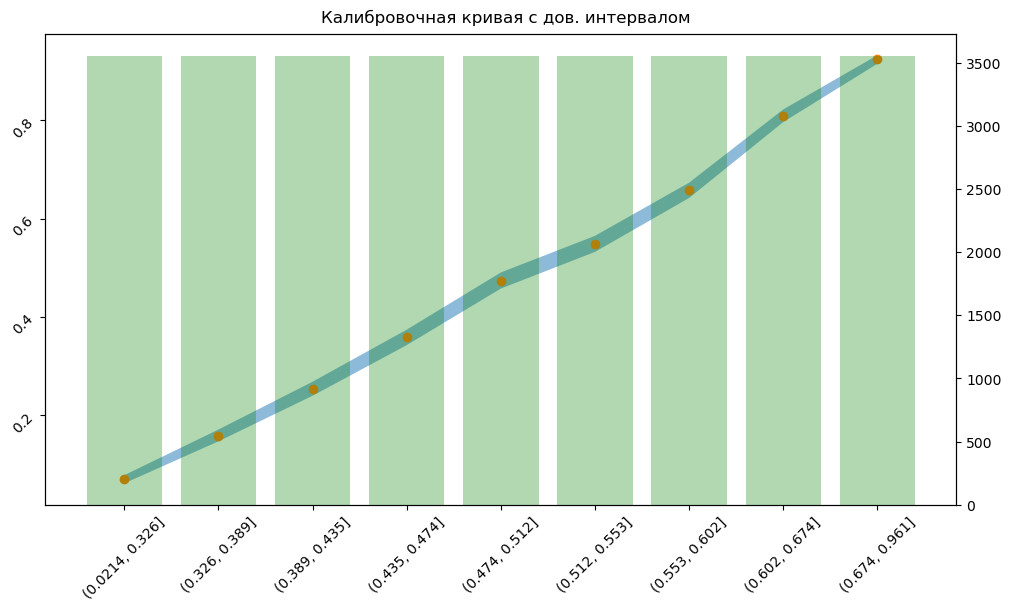

None

In [36]:
print('------------- Графики ------------- ')
metrics_graphs = BinaryClassificationEvaluator(build[target], build_pred, build_pred_proba)
display(metrics_graphs.plot_calibration(path = '', verbose =False))

In [37]:
print('------------- Метрики ------------- ')
y_pred_prob = model.predict_proba(X_test[features])[:, 1]  # Predict probabilities for the positive class
y_pred = (y_pred_prob >= threshold).astype(int) #

methods_dict = {
    'binary': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод', 
    'micro': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.', 
    'macro': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)', 
    'weighted': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'
}

metrics_dict = {
    'Accuracy': round(accuracy_score(y_test, y_pred), 3),
    'ROC-AUC': round(roc_auc_score(y_test, y_pred_prob), 3), 
}

for metric_methods, desription in methods_dict.items():
    metrics_dict[metric_methods] = {
        'Метрики': {
            'Precision': round(precision_score(y_test, y_pred, average = metric_methods), 3),
            "Recall"   : round(recall_score(y_test, y_pred, average = metric_methods), 3),
            "F1"       : round(f1_score(y_test, y_pred, average = metric_methods), 3)
        },
        'Описание': desription
}

display(metrics_dict)


------------- Метрики ------------- 


{'Accuracy': 0.617,
 'ROC-AUC': 0.663,
 'binary': {'Метрики': {'Precision': 0.593, 'Recall': 0.603, 'F1': 0.598},
  'Описание': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод'},
 'micro': {'Метрики': {'Precision': 0.617, 'Recall': 0.617, 'F1': 0.617},
  'Описание': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.'},
 'macro': {'Метрики': {'Precision': 0.616, 'Recall': 0.616, 'F1': 0.616},
  'Описание': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)'},
 'weighted': {'Метрики': {'Precision': 0.618, 'Recall': 0.617, 'F1': 0.617},
  'Описание': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'}}

МАТРИЦА ОШИБОК
ROC-AUC: 0.6629114248230461


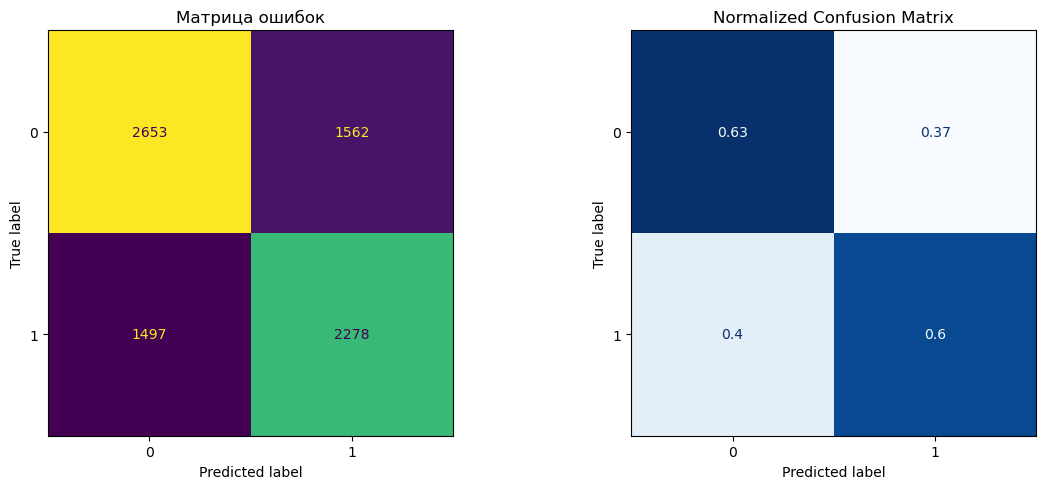

In [38]:
print('МАТРИЦА ОШИБОК')

error_matrix(X_test[features], y_test, model,threshold)

------------- Графики ------------- 


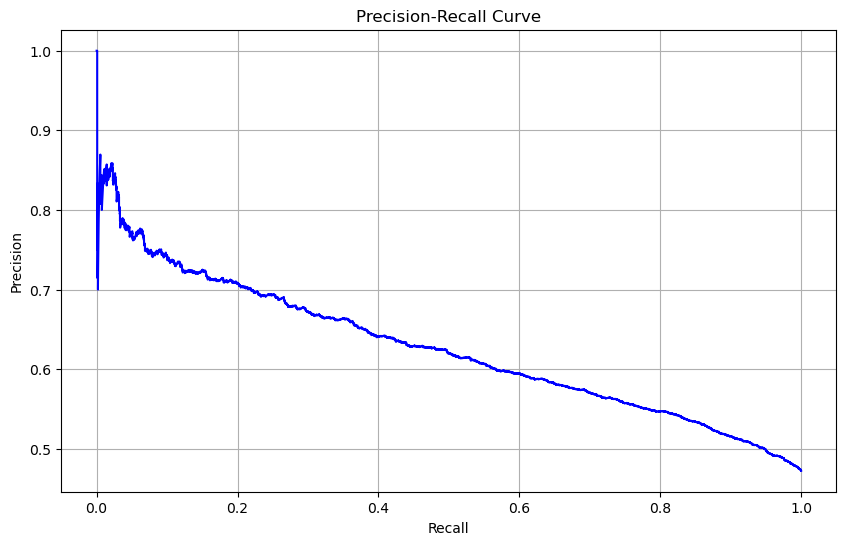

None

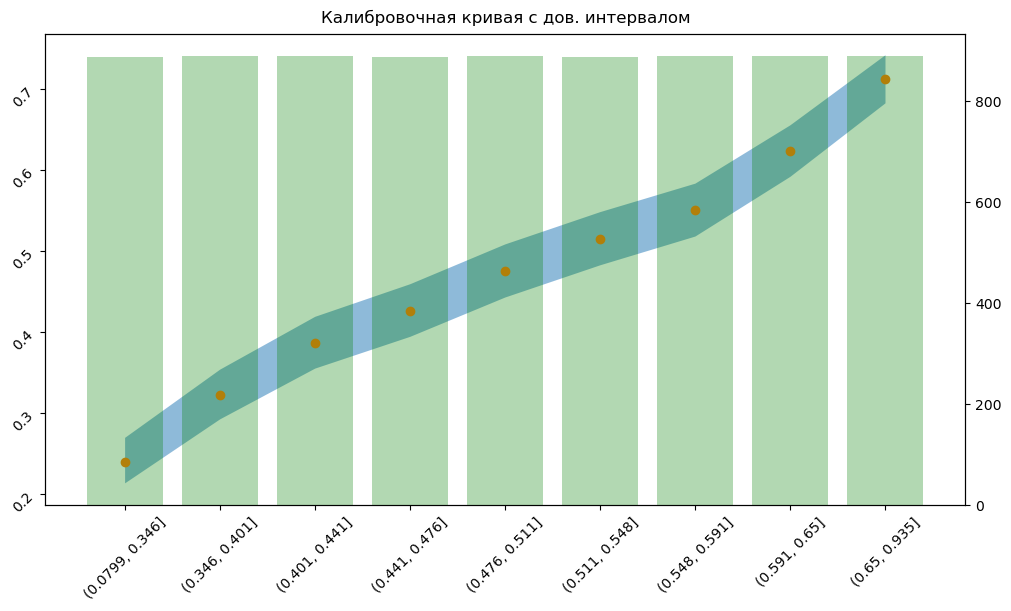

None

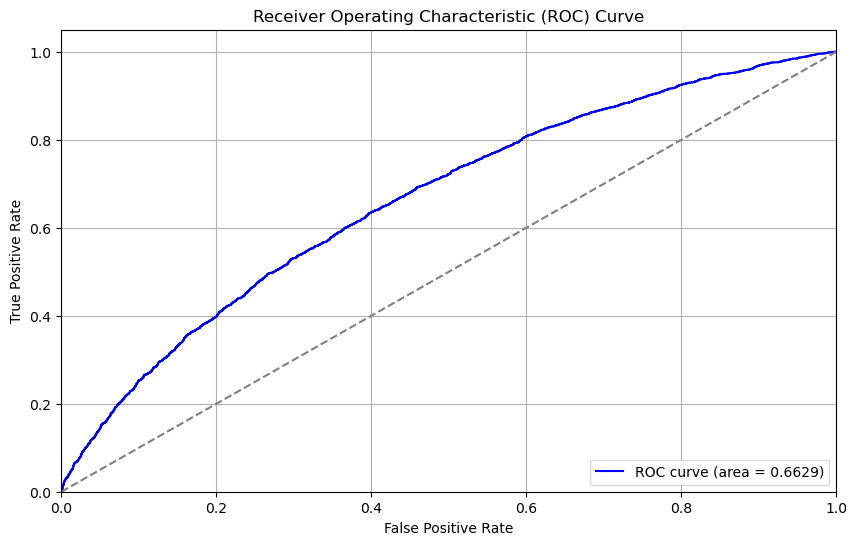

None

In [39]:
print('------------- Графики ------------- ')
metrics_graphs = BinaryClassificationEvaluator(y_test, y_pred, y_pred_prob)
display(metrics_graphs.plot_precision_recall_curve(path = '', verbose =False))
display(metrics_graphs.plot_calibration(path = '', verbose =False))
display(metrics_graphs.plot_roc_curve(path = '', verbose =False))

# Анализ по decile

In [40]:
y_pred_prob_build = model.predict_proba(build[features])[:,1]
# 1. Собираем DataFrame
df_lift = pd.DataFrame({
    'y_true': build[target].values,
    'y_score': y_pred_prob_build
})

# 2. Сортируем по скору (по убыванию)
df_lift = df_lift.sort_values('y_score', ascending=False).reset_index(drop=True)

# 3. Добавляем номер дециля (1 = top 10%)
df_lift['decile'] = pd.qcut(
    df_lift.index,
    q=20,
    labels=False
) + 1

# 4. Базовый CTR по всему тесту
base_ctr = df_lift['y_true'].mean()

# 5. Агрегация по децилям
decile_stats = (
    df_lift
    .groupby('decile')
    .agg(
        mean_score  = ('y_score', 'mean'),
        min_score   = ('y_score', 'min'),
        max_score   = ('y_score', 'max'),
        bids = ('y_true', 'count'),
        clicks      = ('y_true', 'sum'),     
    )
    .reset_index()
    .sort_values('decile')
)

# 6. CTR и Lift
decile_stats['ctr'] = decile_stats['clicks'] / decile_stats['bids']
decile_stats['lift'] = decile_stats['ctr'] / base_ctr

# 7. Cumulative Gain
total_clicks = decile_stats['clicks'].sum()
decile_stats['cum_clicks'] = decile_stats['clicks'].cumsum()
decile_stats['gain'] = decile_stats['cum_clicks'] / total_clicks

# 8. Красивое форматирование
decile_stats['ctr'] = decile_stats['ctr'].round(4)
decile_stats['lift'] = decile_stats['lift'].round(3)
decile_stats['gain'] = decile_stats['gain'].round(3)
decile_stats['mean_score'] = decile_stats['mean_score'].round(2)
decile_stats['min_score'] = decile_stats['min_score'].round(2)
decile_stats['max_score'] = decile_stats['max_score'].round(2)
decile_stats_build = decile_stats.copy()
decile_stats_build

,decile,mean_score,min_score,max_score,bids,clicks,ctr,lift,cum_clicks,gain
0,1,0.790,0.740,0.960,1598,1522,0.952,2.016,1522,0.101
1,2,0.710,0.680,0.740,1598,1451,0.908,1.922,2973,0.197
2,3,0.660,0.640,0.680,1598,1375,0.861,1.821,4348,0.288
3,4,0.630,0.610,0.640,1598,1280,0.801,1.695,5628,0.373
4,5,0.600,0.590,0.610,1598,1153,0.722,1.527,6781,0.449
5,6,0.580,0.570,0.590,1597,1023,0.641,1.356,7804,0.517
6,7,0.560,0.550,0.570,1598,1006,0.629,1.332,8810,0.583
7,8,0.540,0.530,0.550,1598,876,0.548,1.160,9686,0.641
8,9,0.520,0.510,0.530,1598,845,0.529,1.119,10531,0.697
9,10,0.500,0.490,0.510,1598,799,0.500,1.058,11330,0.750


In [41]:
bins = (
    decile_stats_build
    .sort_values('decile')
    [['decile', 'min_score', 'max_score', 'ctr', 'lift']]
    .reset_index(drop=True)
)

bins.loc[bins['max_score'].idxmax(), 'max_score'] = 1
bins.loc[bins['min_score'].idxmin(), 'min_score'] = 0
intervals = pd.IntervalIndex.from_arrays(
    bins['min_score'],
    bins['max_score'],
    closed='left'
)
intervals[:10]

IntervalIndex([ [0.74, 1.0), [0.68, 0.74), [0.64, 0.68), [0.61, 0.64),
               [0.59, 0.61), [0.57, 0.59), [0.55, 0.57), [0.53, 0.55),
               [0.51, 0.53), [0.49, 0.51)],
              dtype='interval[float64, left]')

In [24]:
scoring_lift = bins[['min_score', 'max_score', 'lift']]

In [25]:
y_pred_prob_test = model.predict_proba(test[features])[:, 1]

df_test = pd.DataFrame({
    'y_true': test[target].values,
    'y_score': y_pred_prob_test
})

df_test['decile'] = pd.cut(
    df_test['y_score'],
    bins=intervals
)

# вместо интервалов подставляем номер дециля
df_test['decile'] = df_test['decile'].map(dict(zip(intervals, bins['decile'])))

# 5. Агрегация по децилям
decile_stats = (
    df_test
    .groupby(['decile'])
    .agg(

        min_score   = ('y_score', 'min'),
        max_score   = ('y_score', 'max'),
        mean_score  = ('y_score', 'mean'),
        bids = ('y_true', 'count'),
        clicks = ('y_true', 'sum'), 
        
    )
    .reset_index()
    .sort_values('decile')
)
decile_stats      = decile_stats_build[['decile', 'lift']].merge(decile_stats)
decile_stats.columns = ['decile', 'lift',  'min_score', 'max_score', 'mean_score', 'bids', 'clicks']
# 6. CTR и Lift
decile_stats['ctr_test'] = decile_stats['clicks'] / decile_stats['bids']
decile_stats['lift_test'] = decile_stats['ctr_test'] / base_ctr

# 7. Cumulative Gain
total_clicks = decile_stats['clicks'].sum()
decile_stats['cum_clicks'] = decile_stats['clicks'].cumsum()
decile_stats['gain'] = decile_stats['cum_clicks'] / total_clicks

# 8. Красивое форматирование
decile_stats['ctr_test'] = decile_stats['ctr_test'].round(4)
decile_stats['lift_test'] = decile_stats['lift_test'].round(3)
decile_stats['gain'] = decile_stats['gain'].round(3)
decile_stats['mean_score'] = decile_stats['mean_score'].round(2)
decile_stats['min_score'] = decile_stats['min_score'].round(2)
decile_stats['max_score'] = decile_stats['max_score'].round(2)
decile_stats_test = decile_stats.copy()
decile_stats_test

,decile,lift,min_score,max_score,mean_score,bids,clicks,ctr_test,lift_test,cum_clicks,gain
0,1,2.025,0.710,0.920,0.760,252,201,0.798,1.688,201,0.053
1,2,1.919,0.660,0.710,0.680,360,271,0.753,1.593,472,0.125
2,3,1.801,0.630,0.660,0.640,345,243,0.704,1.491,715,0.189
3,4,1.714,0.600,0.630,0.610,438,294,0.671,1.420,1009,0.267
4,5,1.549,0.580,0.600,0.590,385,233,0.605,1.281,1242,0.329
5,6,1.467,0.560,0.580,0.570,441,249,0.565,1.195,1491,0.395
6,7,1.308,0.540,0.560,0.550,427,221,0.518,1.095,1712,0.454
7,8,1.163,0.520,0.540,0.530,553,307,0.555,1.175,2019,0.535
8,9,1.128,0.510,0.520,0.510,260,118,0.454,0.960,2137,0.566
9,10,0.983,0.490,0.510,0.500,609,278,0.457,0.966,2415,0.640
